***
***

# ***SENTIMENT-DRIVEN TRADING ANALYSIS***

***
***

### About the data

As these are the dataset related to cryptocurrency trading . In this dataset there is traders who trade within a timeframe during buying and selling of their coins. Our main objective is to find those traders who buy/ sell their coin due to any fear or greed. We also need to create a model who will predict the mood of the trader.

***Data Description***

date = date of trading.

account = account number of trader

coin = coin name used for trading at that day

executive price = price of 1 coin token

size token = total number of token purchased/sell by the trader

size USD = executive price * size token

side = the status of the token either buy or sell

start position = amount of tokens purchased when starting the trade

direction = due to market up-down the action done by the trader.

Closed PnL = profit or  loss happen due to the action of the trader while closing it. It is the amount after deducting the fee

transaction hash = transaction id for that trading for generating blockchain. It is a confirmation/settlement id

crossed = is whole amount used for trading or not 

fee = trading fee charged from the trader

order id =  transaction process happen for that trading to generate exchange. It can either be pending, cancelling or completing during the trade.It happen when the first time trade happen.

trade id = id created after the order successfully proceeded. It is mainly used for pnl or winrate calculation. It is generated during trading after 2nd time and onwards.

timestamp IST = date and time of the trading



In [153]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import HalvingRandomSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,accuracy_score,cohen_kappa_score,f1_score
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

In [154]:
# Importing Data

sentiment_info = pd.read_csv('fear_greed_index.csv')
trader_info= pd.read_csv('historical_data.csv')

In [155]:
# Top 5 rows of sentiment_info

sentiment_info.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [156]:
# Top 5 rows of trader_info

trader_info.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00


## PART A : DATA PREPARATION

In [157]:
# finding the shape of the data

print("Shape of market_sentiment data(rows,columns):", sentiment_info.shape)
print("Shape of trader info data(rows,columns):", trader_info.shape)

Shape of market_sentiment data(rows,columns): (2644, 4)
Shape of trader info data(rows,columns): (211224, 16)


In [158]:
# looking for null values

print("Null values in market_sentiment data:\n", sentiment_info.isnull().sum().sum())
print("Null values in trader info data:\n", trader_info.isnull().sum().sum())

Null values in market_sentiment data:
 0
Null values in trader info data:
 0


In [159]:
# Looking for duplicate values

print("Duplicate values present in the market sentiment data: \n",sentiment_info.duplicated().sum())
print("Duplicate values present in the trader info data: \n",trader_info.duplicated().sum())

Duplicate values present in the market sentiment data: 
 0
Duplicate values present in the trader info data: 
 0


In [160]:
# About the data of sentiment_info

print("Information about the market sentiment data:\n")
print(sentiment_info.info())

Information about the market sentiment data:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [161]:
# About the data of trader_info

print("Information about the trader info data:\n")  
print(trader_info.info())

Information about the trader info data:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 no

In [162]:
# 5 point summary of sentiment_info data

sentiment_info.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp,2644.00,1631898885.02,65979674.32,1517463000.00,1574811000.00,1631899800.00,1688988600.00,1746163800.00
value,2644.00,46.98,21.83,5.00,28.00,46.00,66.00,95.00


In [163]:
#  5 point summary of trader_info data

trader_info.describe().T

,count,mean,std,min,25%,50%,75%,max
Execution Price,211224.00,11414.72,29447.65,0.00,4.85,18.28,101.58,109004.00
Size Tokens,211224.00,4623.36,104272.89,0.00,2.94,32.00,187.90,15822438.00
Size USD,211224.00,5639.45,36575.14,0.00,193.79,597.05,2058.96,3921430.72
Start Position,211224.00,-29946.25,673807.42,-14334629.00,-376.23,84.73,9337.28,30509482.00
Closed PnL,211224.00,48.75,919.16,-117990.10,0.00,0.00,5.79,135329.09
Order ID,211224.00,69653876008.97,18357525271.93,173271100.00,59838527992.75,74429390066.00,83355430544.00,90149230487.00
Fee,211224.00,1.16,6.76,-1.18,0.02,0.09,0.39,837.47
Trade ID,211224.00,562854854500788.50,325756470346523.38,0.00,281000000000000.00,562000000000000.00,846000000000000.00,1130000000000000.00
Timestamp,211224.00,1737744290421.54,8689920301.59,1680000000000.00,1740000000000.00,1740000000000.00,1740000000000.00,1750000000000.00


In [164]:
sentiment_info.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


 * As I can find that the date column in sentiment_info and timestamp IST_column in trader_info are related to same thing. So, for merging the data
 I will use this column but before using this I need to convert this into datetime format  and I will create a new column for this in both dataframe 
 so, that I can merge the data on this column easily and also I will use left join for merging the data because 
 I want to keep all the records of trader_info data and only want to add the sentiment info to it.

In [165]:
# Creating a new column 'clean_date' in both dataframes for merging and converting the date columns to datetime format

sentiment_info['clean_date'] = pd.to_datetime(sentiment_info['date'])
trader_info['clean_date'] = pd.to_datetime(trader_info['Timestamp IST'], dayfirst=True).dt.normalize()


In [166]:
# Merge the two dataframes on 'clean_date' using a left join to create a final dataframe.

final_df = pd.merge(trader_info, sentiment_info, on='clean_date', how='left')
final_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,clean_date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00,2024-12-02,1733117400.00,80.00,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00,2024-12-02,1733117400.00,80.00,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00,2024-12-02,1733117400.00,80.00,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00,2024-12-02,1733117400.00,80.00,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00,2024-12-02,1733117400.00,80.00,Extreme Greed,2024-12-02


In [167]:
# Checking the shape of the final dataframe after merging

final_df.shape

(211224, 21)

In [168]:
# Looking for null values in the final dataframe after merging

final_df.isnull().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
clean_date          0
timestamp           6
value               6
classification      6
date                6
dtype: int64

* As I found that there is  6 rows missing after merging the data but all these 6 rows has 4 value missing 

and I found that these rows are redundant foor getting insights . So, I am dropping these rows from the dataset.

In [169]:
# Removing rows with null values in the final dataframe

final_df.dropna(inplace=True)

In [170]:
# Checking for duplicate values in the final dataframe after merging and removing null values

final_df.duplicated().sum()

np.int64(0)

In [171]:
# 5 point summary of the final dataframe after merging and removing null values

final_df.describe(include=np.number).T

,count,mean,std,min,25%,50%,75%,max
Execution Price,211218.00,11415.05,29448.01,0.00,4.86,18.28,101.89,109004.00
Size Tokens,211218.00,4623.34,104274.37,0.00,2.94,32.00,187.89,15822438.00
Size USD,211218.00,5639.19,36575.57,0.00,193.79,597.02,2058.88,3921430.72
Start Position,211218.00,-29946.71,673816.99,-14334629.00,-376.07,84.77,9337.70,30509482.00
Closed PnL,211218.00,48.55,917.99,-117990.10,0.00,0.00,5.79,135329.09
Order ID,211218.00,69654699303.11,18357136086.99,173271100.00,59842228764.00,74429390066.00,83355430544.00,90149230487.00
Fee,211218.00,1.16,6.76,-1.18,0.02,0.09,0.39,837.47
Trade ID,211218.00,562850620151097.69,325754134654348.19,0.00,281000000000000.00,562000000000000.00,846000000000000.00,1130000000000000.00
Timestamp,211218.00,1737744510411.04,8689945699.51,1680000000000.00,1740000000000.00,1740000000000.00,1740000000000.00,1750000000000.00
timestamp,211218.00,1738301306.74,8029301.73,1682919000.00,1735623000.00,1740375000.00,1743571800.00,1746077400.00


In [172]:
# Number of unique values in each column of the final dataframe after merging and removing null values

final_df.nunique()

Account                 32
Coin                   246
Execution Price      60160
Size Tokens          59300
Size USD            118488
Side                     2
Timestamp IST        27974
Start Position      196917
Direction               12
Closed PnL           90714
Transaction Hash    101181
Order ID             50552
Crossed                  2
Fee                 138796
Trade ID              2810
Timestamp                7
clean_date             479
timestamp              479
value                   73
classification           5
date                   479
dtype: int64

***Insights***

1) I found date column is the common column for merging these two  tables so, I merge these table through date column. I need all the rows from both tables so I use left join here for merging it.
2) As I found no missing  values present  in the data when I check both dataset separately. But after merging I found 6 rows which has very less infomation. I found those rows redundant that's why I remove those rows from the data.
3) I also found that there is no duplicacy present in the data so, I don't need to handle duplicate rows in the data. 
4) After analysing the data , I found that this data is of 32 traders who trade in cryptocurrency  and we have total 246 coins which used for these tradings by traders.


#### Analyzing the data

In [173]:
final_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'clean_date', 'timestamp', 'value', 'classification',
       'date'],
      dtype='object')

In [174]:
final_df['Closed PnL'].unique()

array([   0.      , 3008.231185,   30.741534, ..., -112.5773  ,
        -22.4402  ,  -53.9063  ])

In [175]:
# dividing data into numericals and categoricals for better understanding

num_cols = ['Fee','value','Size Tokens','Execution Price','Size USD','Closed PnL','Start Position']
cat_cols = ['Side','Direction','classification','Crossed']

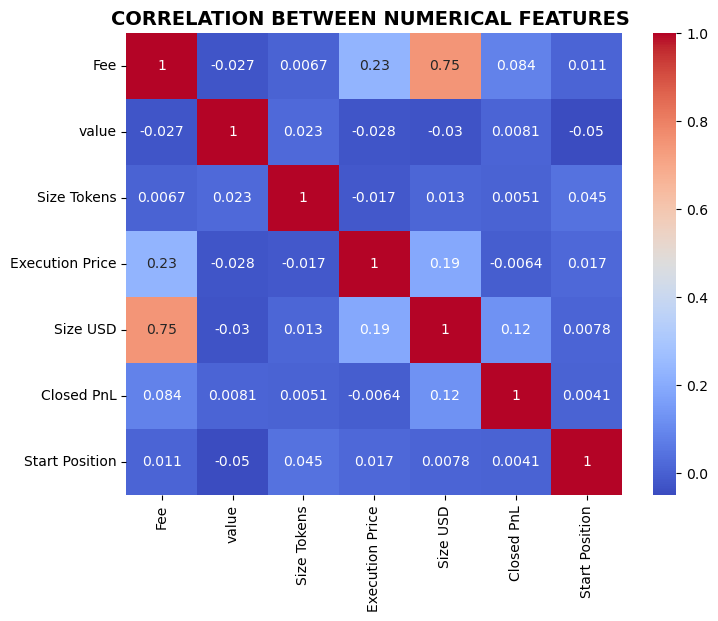

In [176]:
# Correlation between features in the final dataframe

plt.figure(figsize=(8,6))
plt.title('CORRELATION BETWEEN NUMERICAL FEATURES ', fontsize=14, fontweight='bold')
sns.heatmap(final_df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

***Inference***

There is direct relation between size USD and fee as the size of tokens increases the total price  for trading goes increases and this effect the increase of fee charging. while rest of the variables has not much relation between variables.

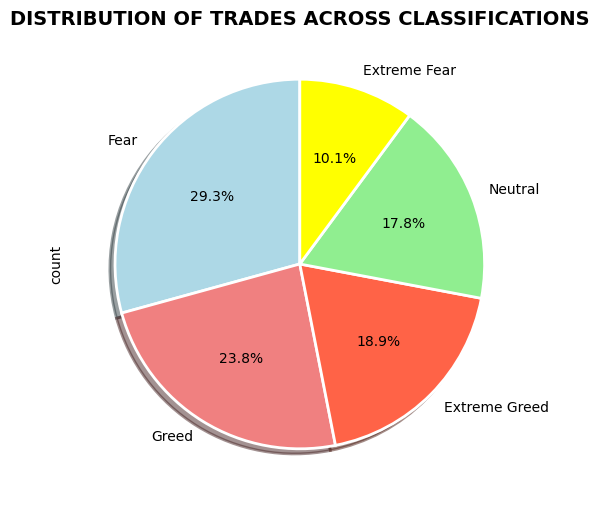

In [177]:
# Visualization of the distribution of trades across classifications in the final dataframe

plt.figure(figsize=(8,6))
plt.title('DISTRIBUTION OF TRADES ACROSS CLASSIFICATIONS', fontsize=14, fontweight='bold')
final_df['classification'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                                colors=['lightblue', 'lightcoral','tomato','lightgreen','yellow'], startangle=90,shadow=True,
                                                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
                                               
plt.show()

***Inference***

There is high trader of fear mood and the 2nd most trader are in the mood of greed.This shows that most of the traders are new or not having much knowledge about the trading that's why they are in a fear mood of losing the amount which they invested in the market.

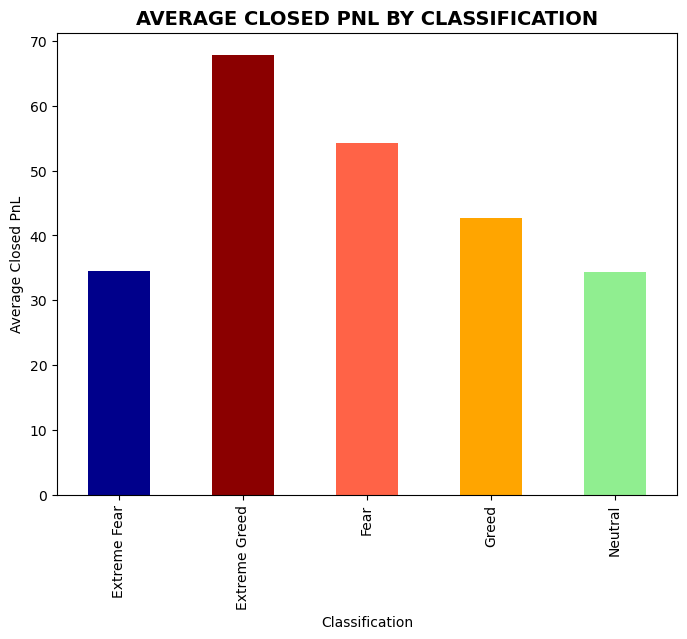

In [178]:
# Visualization of the average closed PnL by classification in the final dataframe

plt.figure(figsize=(8,6))
final_df.groupby('classification')['Closed PnL'].mean().plot(kind='bar',color=['darkblue','darkred','tomato','orange','lightgreen'])
plt.title('AVERAGE CLOSED PNL BY CLASSIFICATION', fontsize=14, fontweight='bold')
plt.xlabel('Classification')
plt.ylabel('Average Closed PnL')
plt.show()

In [179]:
# Creating a column to calculate the percentage of PnL with respect to the size of the trade in USD

final_df['PnL_Percentage'] = (final_df['Closed PnL'] / final_df['Size USD']) * 100

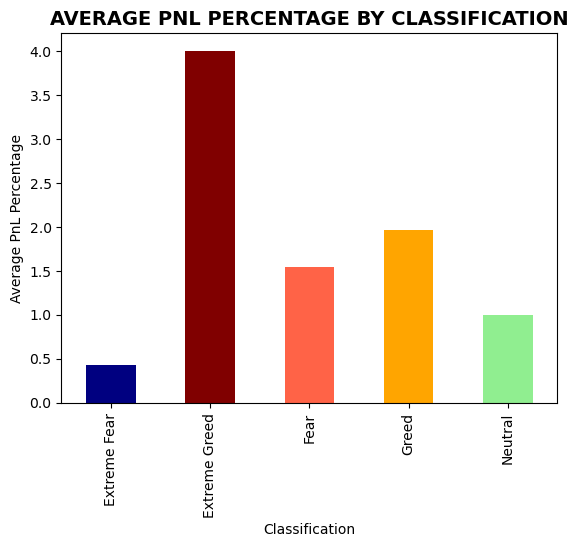

In [180]:
# Visualization of the average PnL percentage by classification in the  final dataframe

final_df.groupby('classification')['PnL_Percentage'].mean().plot(kind='bar', color=['navy','maroon','tomato','orange','lightgreen'])
plt.title('AVERAGE PNL PERCENTAGE BY CLASSIFICATION', fontsize=14, fontweight='bold')
plt.xlabel('Classification')
plt.ylabel('Average PnL Percentage')
plt.show()

In [181]:
#  creating a column to classify trades as profitable or unprofitable based on the Closed PnL

final_df['is_profitable'] = np.where(final_df['Closed PnL'] > 0, 'profitable', 'unprofitable')

final_df['is_profitable_encoded'] = np.where(final_df['is_profitable'] == 'profitable', 1, 0)

# Win rate by classification

win_rate = final_df.groupby('classification')['is_profitable_encoded'].mean() * 100

In [182]:
win_rate

classification
Extreme Fear    37.06
Extreme Greed   46.49
Fear            42.08
Greed           38.48
Neutral         39.70
Name: is_profitable_encoded, dtype: float64

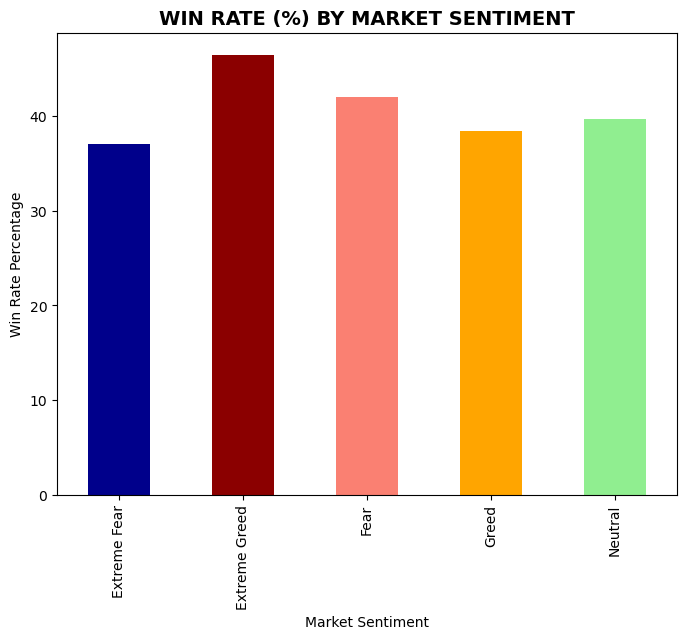

In [183]:
# Visualizing the win rate by classification

plt.figure(figsize=(8,6))
win_rate.plot(kind='bar', color=['darkblue', 'darkred','salmon','orange','lightgreen'])
plt.title('WIN RATE (%) BY MARKET SENTIMENT', fontsize=14, fontweight='bold')
plt.ylabel('Win Rate Percentage')
plt.xlabel('Market Sentiment')
plt.show()

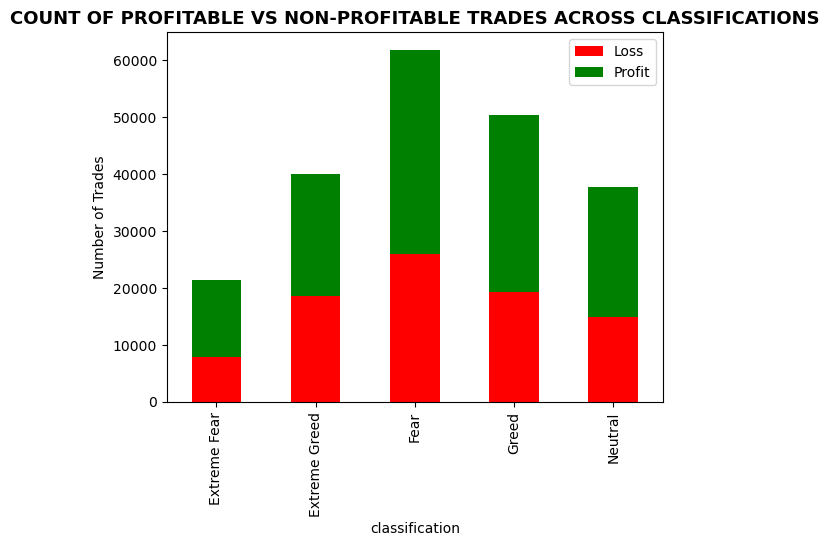

In [184]:
# Visualizing the distribution of profitable vs non-profitable trades across classifications

dist = pd.crosstab(final_df['classification'], final_df['is_profitable'])

dist.plot(kind='bar', stacked=True, color=['red', 'green'])
plt.title('COUNT OF PROFITABLE VS NON-PROFITABLE TRADES ACROSS CLASSIFICATIONS', fontsize=13, fontweight='bold')
plt.ylabel('Number of Trades')
plt.legend(['Loss', 'Profit'])
plt.show()

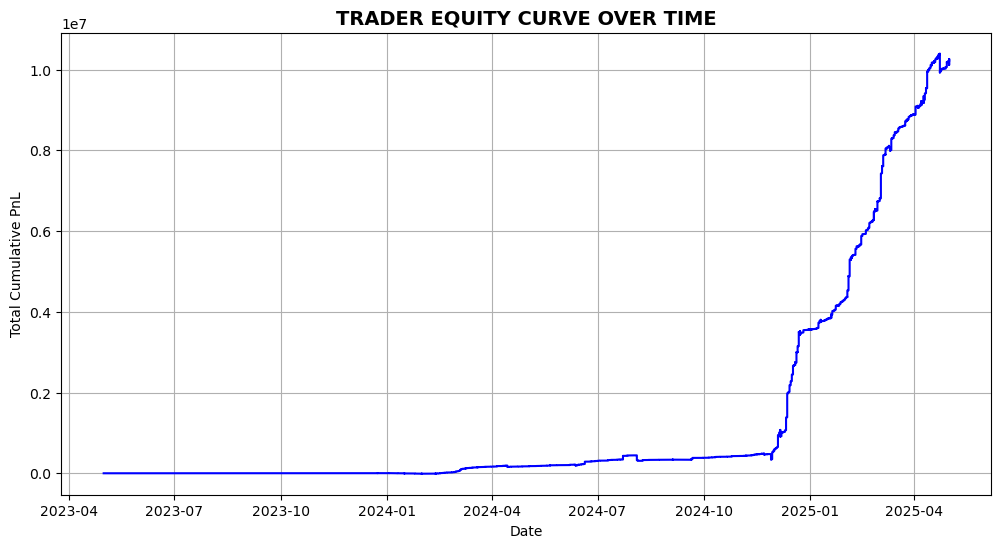

In [185]:
# Visualizing the equity curve of the trader over time based on the cumulative PnL

final_df = final_df.sort_values('clean_date')
final_df['Cumulative_PnL'] = final_df['Closed PnL'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(final_df['clean_date'], final_df['Cumulative_PnL'], color='blue')
plt.title('TRADER EQUITY CURVE OVER TIME', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Cumulative PnL')
plt.grid(True)
plt.show()

***Inference***

By looking all the above charts and this line chart . I analyze that the market is stable from april 2023 to decemeber 2024. There is not much profit or loss occur during that time . This shows the market is in break even point while when the 1st quarter of year 2025 comes there is high jump of market towards the profit. This shows that traders are taking more risk. They are now in that field which helps the market to grow. As we can see very high growth in 2nd quarter of 2025 . This shows that if market goes in reverse case this will lead to severe loss.

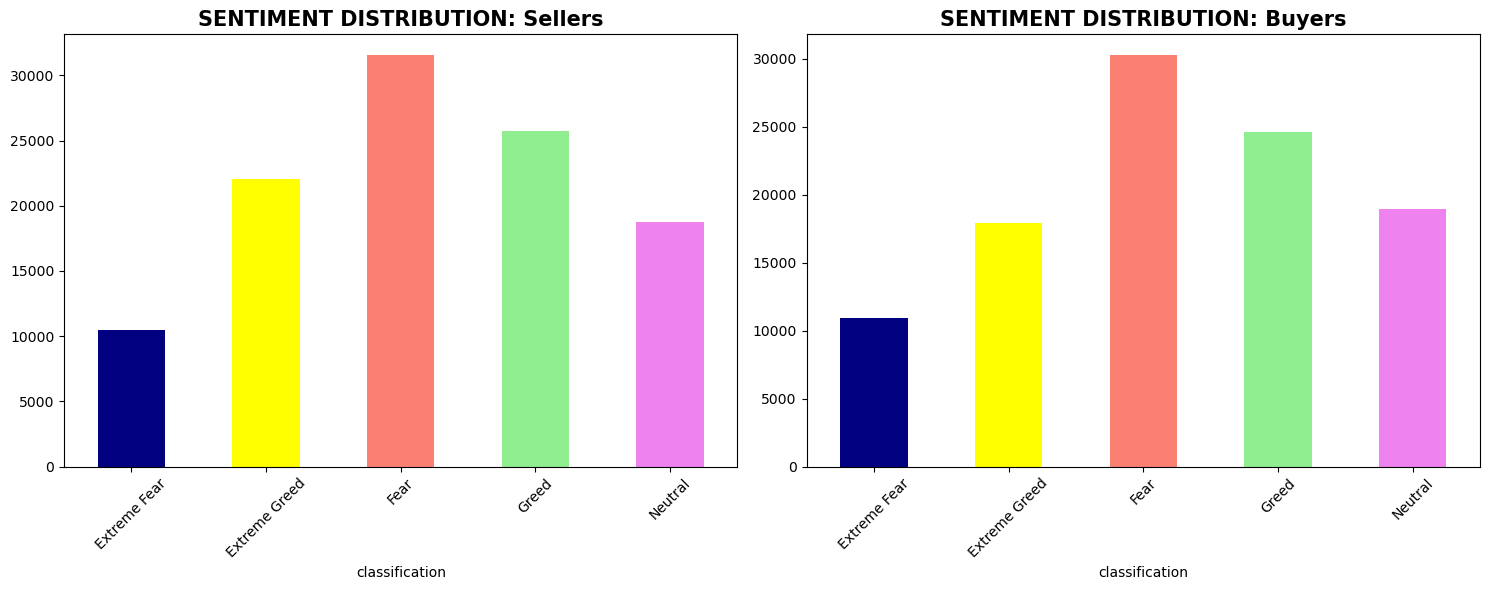

In [186]:
# Visualizing the distribution of trade sides (long vs short) across classifications in the final dataframe

bias = pd.crosstab(final_df['classification'], final_df['Side'])
sell = bias['SELL']
buy = bias['BUY']


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Sentiment Distribution for Winners

sell.plot(kind='bar', ax=axes[0], color=['navy','yellow','salmon','lightgreen','violet'])
axes[0].set_title('SENTIMENT DISTRIBUTION: Sellers',fontsize=15, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Sentiment Distribution for Losers
buy.plot(kind='bar', ax=axes[1], color=['navy','yellow','salmon','lightgreen','violet'])
axes[1].set_title('SENTIMENT DISTRIBUTION: Buyers',fontsize=15, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

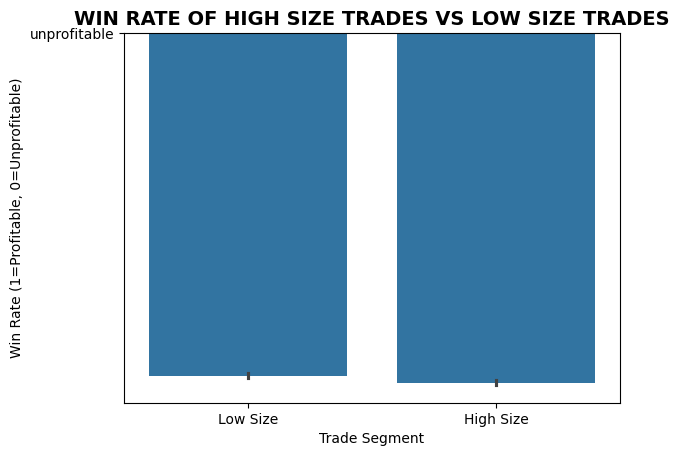

In [187]:
# Visualizing the win rate of high size trades vs low size trades based on the median size of the trades in USD

median_size = final_df['Size USD'].median()
final_df['trade_segment'] = np.where(final_df['Size USD'] > median_size, 'High Size', 'Low Size')

sns.barplot(x='trade_segment', y='is_profitable', data=final_df)
plt.title('WIN RATE OF HIGH SIZE TRADES VS LOW SIZE TRADES', fontsize=14, fontweight='bold')
plt.xlabel('Trade Segment')
plt.ylabel('Win Rate (1=Profitable, 0=Unprofitable)') 
plt.show()

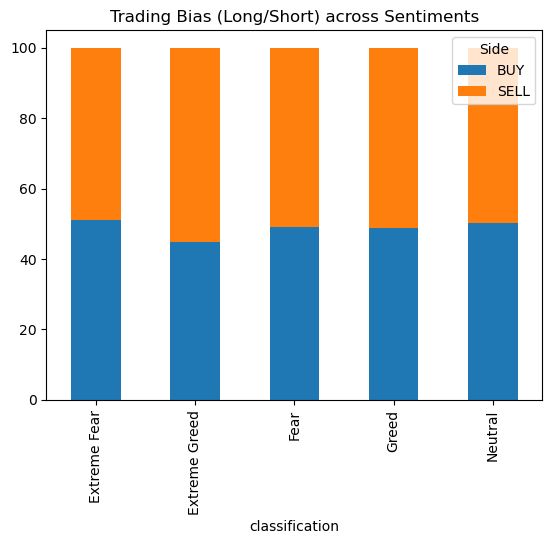

In [188]:
# Crosstab for Sentiment and Side

bias_df = pd.crosstab(final_df['classification'], final_df['Side'], normalize='index') * 100

bias_df.plot(kind='bar', stacked=True)
plt.title('Trading Bias (Long/Short) across Sentiments')
plt.show()

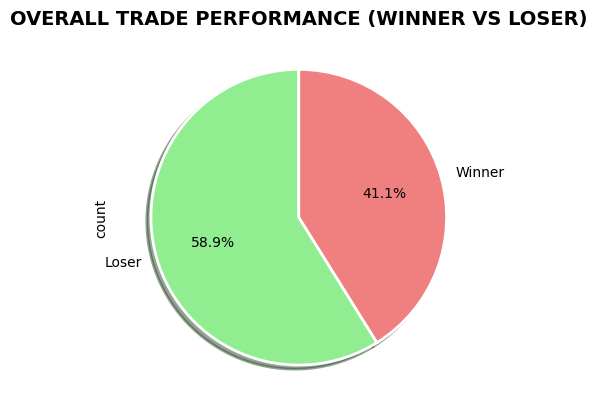

In [189]:
# looking for loss and profit distribution in the final dataframe

final_df['performance_segment'] = np.where(final_df['Closed PnL'] > 0, 'Winner', 'Loser')
performance_counts = final_df['performance_segment'].value_counts()
performance_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], startangle=90, shadow=True, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('OVERALL TRADE PERFORMANCE (WINNER VS LOSER)', fontsize=14, fontweight='bold')
plt.show()

***Inference***

As this chart is visualizing, the winner is less than loser. But, in actual this shows the growth in the market . As the time passes, traders are taking more risk and this helps to increase the market .

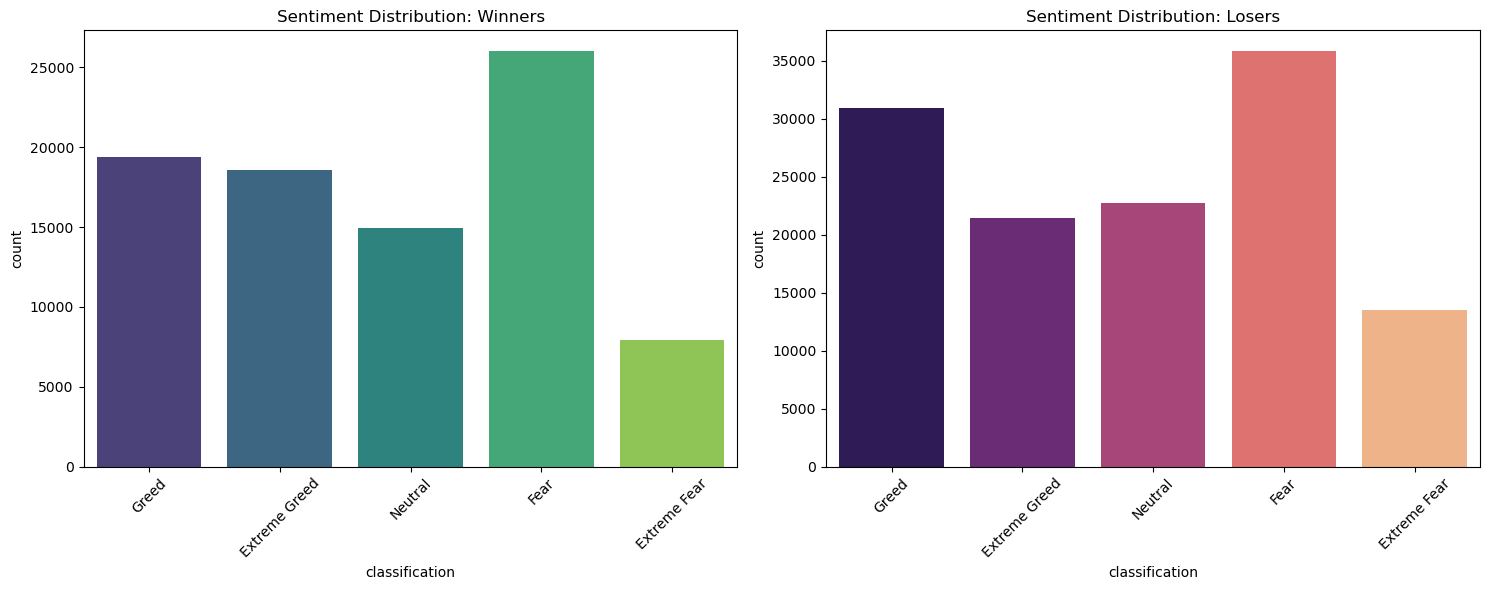

In [190]:
# calculating the distribution of winners and losers across classifications in the final dataframe

winners = final_df[final_df['Closed PnL'] > 0]
losers = final_df[final_df['Closed PnL'] <= 0]


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1: Sentiment Distribution for Winners

sns.countplot(x='classification', data=winners, ax=axes[0], palette='viridis')
axes[0].set_title('Sentiment Distribution: Winners')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Sentiment Distribution for Losers
sns.countplot(x='classification', data=losers, ax=axes[1], palette='magma')
axes[1].set_title('Sentiment Distribution: Losers')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

***
***

***Insights***

1) Through correlation visualization , I found that there is postive correlation between token size and fee. As the token size increase the fee amount also increases rest all the other columns have not any other strong correlation like these 2.
2) extreme greed traders has high avg closed pnl than the others while extreme fear traders have very less p&l among all those classification of moods
3) Through win rate column, profitable percentage columns . I can say that extreme greed people get highest profit among all moods of traders while extreme fear traders get very less profit among other. 
4) The line chart shows from april 2023 to nov 2024 there is not a gowth of market this shows that trader is not trying to take much risk while after jan 2025 there is high growth in the market. This shows that the trader is now become an extreme greed people that's why market is growing. This can be good  for market but if the market goes to reverse. This will be highly effected to traders and market.
5) Profit earn trader is less than the loss . This is happen may be the greedy people taking very high risk and the fear trader suddenly closed their account due to this they got loss in transaction.if we conect this through  line chart we can identify that the  loss is recovering as the time passes . As the year 2025 comes the loss goes decreases. This shows that may be in future there is high chances that the people will trying to take more risk and this will grow the market.
6) In fear cases , there is less profit while in greed mood traders there is high chances of getting profit and grow the market.

***
***

#### Questions to Answer

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days? 

    Ans. Yes, as the traders mood become greed means as the trader trying to take more risk there is high chances of getting profit while as the trader mood become fearful there is very less chances that they will get profit. This shows there is positive correlation between greed and profit while there is negative correlation between fear and profit.


2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short 
bias, position sizes)? 
    Yes, As I observed there is significant increase in trading activity at the time of extreme greed. This indicates the extreme greed are more active traders while extreme fear traders became less active traders as their is any ups and downs in the market.This shows that at greed time the size of tokens goes increase while in fear time there is a chances not buying more tokens and this indicates the greed driven traders took more risk than the fear driven traders.
    

***

#### Looking for outliers present in the data

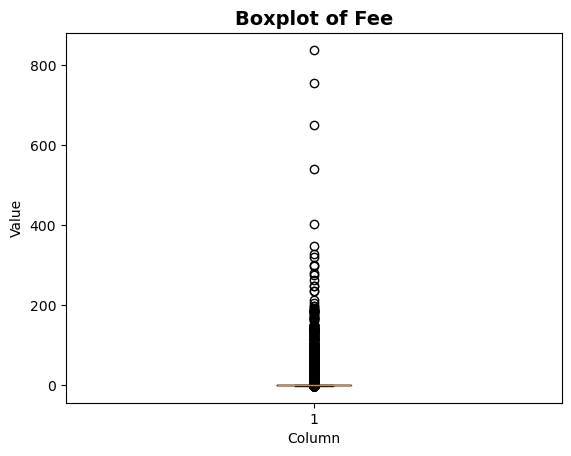

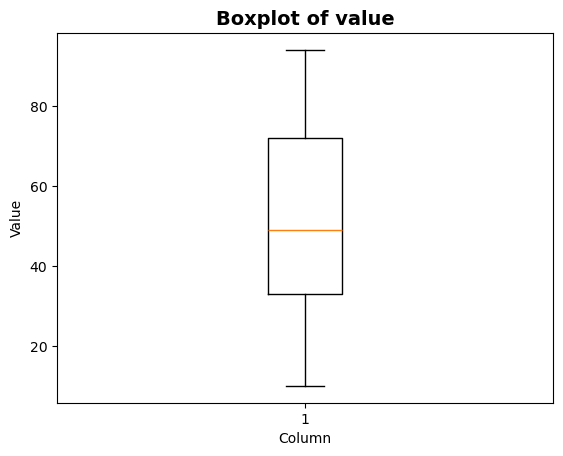

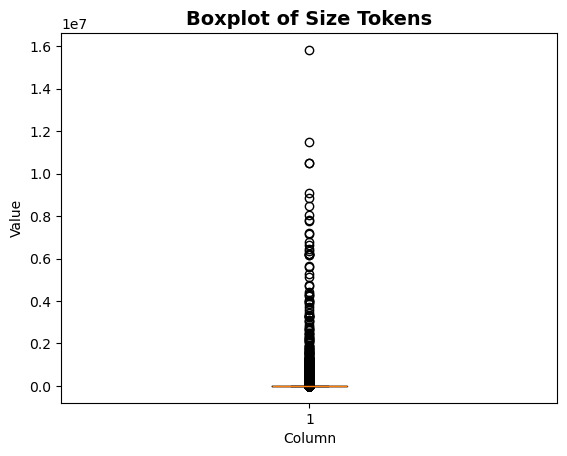

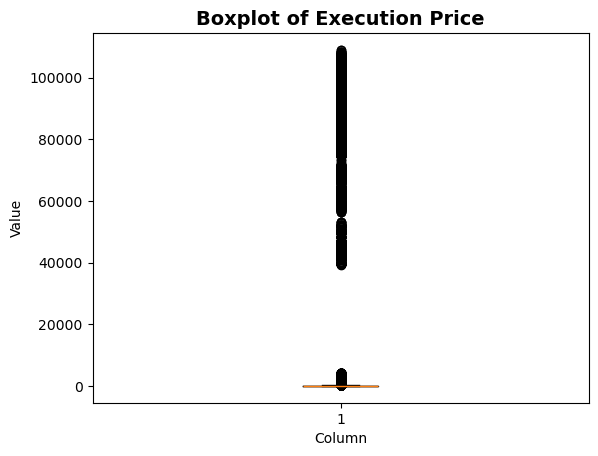

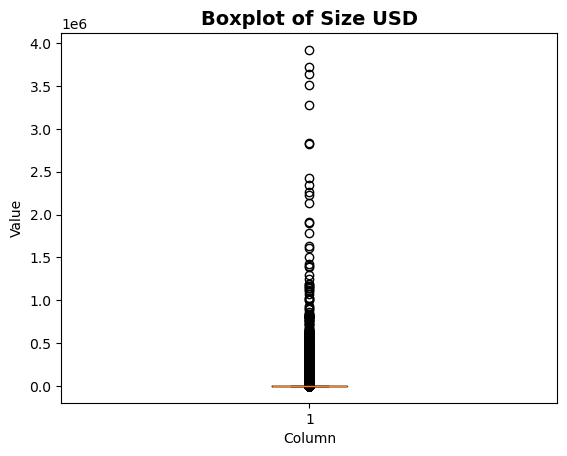

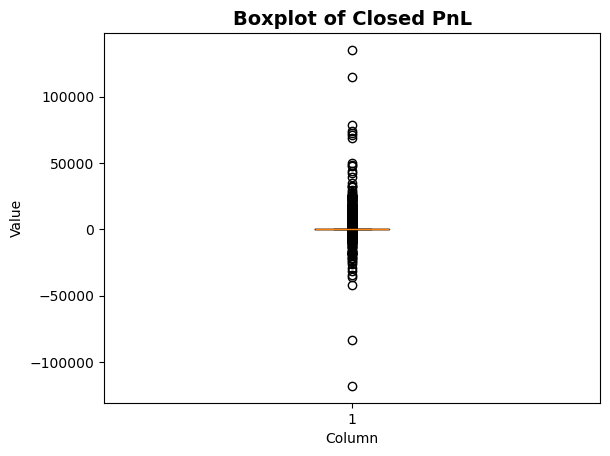

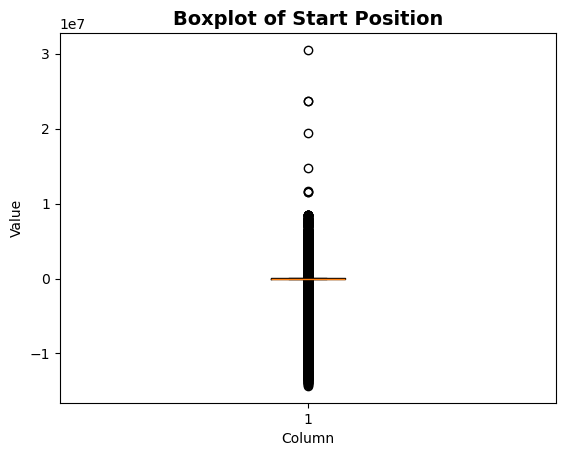

In [191]:

for i in final_df[num_cols]:
    plt.boxplot(final_df[i])
    plt.title(f'Boxplot of {i}', fontsize=14, fontweight='bold')
    plt.ylabel('Value')
    plt.xlabel('Column')
    plt.show()

***Inference***

As I analyse that there is extreme outleirs present in the data but . Capping all those outliers is not good for prediction or I cannot remove any outleir. Because in trading cases outlier cases is common. So, I am capping only most extreme outliers

In [192]:
# for capping outleirs

for i in final_df[num_cols]:
    Q1 = final_df[i].quantile(0.25)
    Q3 = final_df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    final_df[i] = np.where(final_df[i] < lower_bound, lower_bound, final_df[i])
    final_df[i] = np.where(final_df[i] > upper_bound, upper_bound, final_df[i])

In [193]:
# As I found the my target column that is classification has 5 classes and for prediction this is very complicated to analyse
# So, I am combining the classes into 3 classes  as follows:
# 1. 'Extreme Fear' and 'Fear' as 'Bearish' 
# 2. 'Neutral' remains 'Neutral'
# 3. 'Greed' and 'Extreme Greed' as 'Bullish'

final_df['classification_combine'] = final_df['classification'].replace({'Extreme Fear': 'Bearish', 'Fear': 'Bearish', 'Greed': 'Bullish', 'Extreme Greed': 'Bullish'})


In [194]:
final_df.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,clean_date,timestamp,value,classification,date,PnL_Percentage,is_profitable,is_profitable_encoded,Cumulative_PnL,trade_segment,performance_segment,classification_combine
83771,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,247.45,0.07,137.08,BUY,01-05-2023 01:06,0.18,Open Long,0.00,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.00,0.00,1680000000000.00,2023-05-01,1682919000.00,63.00,Greed,2023-05-01,0.00,unprofitable,0,0.00,Low Size,Loser,Bullish
83770,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,247.45,0.08,156.39,BUY,01-05-2023 01:06,0.10,Open Long,0.00,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.00,0.00,1680000000000.00,2023-05-01,1682919000.00,63.00,Greed,2023-05-01,0.00,unprofitable,0,0.00,Low Size,Loser,Bullish


In [195]:
# I am coping the final dataframe into a new dataframe for further analysis and model building

data = final_df.copy()
data.head(2)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,clean_date,timestamp,value,classification,date,PnL_Percentage,is_profitable,is_profitable_encoded,Cumulative_PnL,trade_segment,performance_segment,classification_combine
83771,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,247.45,0.07,137.08,BUY,01-05-2023 01:06,0.18,Open Long,0.00,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.00,0.00,1680000000000.00,2023-05-01,1682919000.00,63.00,Greed,2023-05-01,0.00,unprofitable,0,0.00,Low Size,Loser,Bullish
83770,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,247.45,0.08,156.39,BUY,01-05-2023 01:06,0.10,Open Long,0.00,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.00,0.00,1680000000000.00,2023-05-01,1682919000.00,63.00,Greed,2023-05-01,0.00,unprofitable,0,0.00,Low Size,Loser,Bullish


In [196]:
data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'clean_date', 'timestamp', 'value', 'classification',
       'date', 'PnL_Percentage', 'is_profitable', 'is_profitable_encoded',
       'Cumulative_PnL', 'trade_segment', 'performance_segment',
       'classification_combine'],
      dtype='object')

In [198]:
# As I found date,clean_date,timestamp IST,classification,is_profitable,cumulative Pnl,coin,account,trade_id,order_id these are not needed for my model
# building so I am dropping these columns from the data dataframe.
# As I found that there is correlation between size USd and fee so , I am removing one variable out of these 2 to prevent any multicolinearity issue.

columns = ['date', 'clean_date','Transaction Hash','Size USD', 'PnL_Percentage','Timestamp IST','Timestamp' ,'classification', 'is_profitable', 'Cumulative_PnL', 'Coin', 'Account', 'Trade ID', 'Order ID','value']

data.drop(columns=columns, inplace=True)

In [199]:
data.head(2)

,Execution Price,Size Tokens,Side,Start Position,Direction,Closed PnL,Crossed,Fee,timestamp,is_profitable_encoded,trade_segment,performance_segment,classification_combine
83771,247.45,0.07,BUY,0.18,Open Long,0.00,True,0.00,1682919000.00,0,Low Size,Loser,Bullish
83770,247.45,0.08,BUY,0.10,Open Long,0.00,True,0.00,1682919000.00,0,Low Size,Loser,Bullish


In [200]:
# Now I need to encode the variables for model building.
# I am using label encoding of classification_combine, crossed, side,direction and performance_segemnt column
# and I am using one hot for trade_segment column


encode = LabelEncoder()

col = ['classification_combine', 'Crossed', 'Side', 'Direction', 'performance_segment']

for i in col:
    data[i] = encode.fit_transform(data[i])



data['trade_segment'] = pd.get_dummies(data['trade_segment'], drop_first=True,dtype='int')

In [202]:
num_cols

['Fee',
 'value',
 'Size Tokens',
 'Execution Price',
 'Size USD',
 'Closed PnL',
 'Start Position']

In [204]:
# Scaling the data. I am using Standard Scaler here

cols = ['Fee','Size Tokens','Execution Price','Closed PnL','Start Position']

scaler = StandardScaler()
data[cols] = scaler.fit_transform(data[cols])

In [205]:
data.head(2)

,Execution Price,Size Tokens,Side,Start Position,Direction,Closed PnL,Crossed,Fee,timestamp,is_profitable_encoded,trade_segment,performance_segment,classification_combine
83771,1.88,-0.73,0,-0.34,6,-0.49,1,-0.78,1682919000.00,0,1,0,1
83770,1.88,-0.73,0,-0.34,6,-0.49,1,-0.78,1682919000.00,0,1,0,1


In [223]:
# splitting the data into two parts independent variable and dependent variable

x = data.drop(columns = ['classification_combine','timestamp'])
y = data['classification_combine']

In [224]:
# Using train test split for splitting data into training and testing part

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.8,random_state=42)

In [225]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(168974, 11) (42244, 11) (168974,) (42244,)


#### Logistic Model

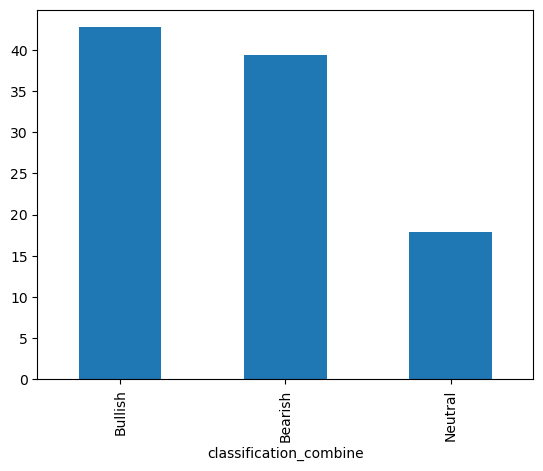

In [226]:
classes= final_df['classification_combine'].value_counts(normalize=True)*100
classes.plot(kind='bar')
plt.show()

* As we can see that bullish class has around 45%  of the data and bearish has  around 40% of the data and neutral has around 15% of the data. There is class imbalance in neutral and other classes so, i am using class_imbalance parameter for model building.

In [227]:
model_lr  = LogisticRegression(class_weight='balanced',multi_class='multinomial',solver='lbfgs',max_iter=1000)
model_lr.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [228]:
model_pred = model_lr.predict(x_test)

In [229]:
print('Accuracy Score',accuracy_score(y_test,model_pred))
print('F1 Score',f1_score(y_test,model_pred,average='macro'))
print('Cohen kappa Score',cohen_kappa_score(y_test,model_pred))
print('\n classification_report\n',classification_report(y_test,model_pred))


Accuracy Score 0.4192548054161538
F1 Score 0.4039019987976095
Cohen kappa Score 0.12228401125106414

 classification_report
               precision    recall  f1-score   support

           0       0.47      0.41      0.44     16690
           1       0.54      0.44      0.48     17986
           2       0.23      0.40      0.29      7568

    accuracy                           0.42     42244
   macro avg       0.41      0.41      0.40     42244
weighted avg       0.46      0.42      0.43     42244



In [230]:
model_pred_train = model_lr.predict(x_train)

print('Accuracy Score',accuracy_score(y_train,model_pred_train))
print('F1 Score',f1_score(y_train,model_pred_train,average='macro'))
print('Cohen kappa Score',cohen_kappa_score(y_train,model_pred_train))
print('\n Classificatio Report\n',classification_report(y_train,model_pred_train))

Accuracy Score 0.42175719341437146
F1 Score 0.4057681656734304
Cohen kappa Score 0.1256088547564309

 Classificatio Report
               precision    recall  f1-score   support

           0       0.47      0.41      0.44     66547
           1       0.55      0.44      0.49     72309
           2       0.23      0.40      0.29     30118

    accuracy                           0.42    168974
   macro avg       0.42      0.42      0.41    168974
weighted avg       0.46      0.42      0.43    168974



In [231]:
print('Confusion Matrix',confusion_matrix(y_test,model_pred))

Confusion Matrix [[6810 4597 5283]
 [5215 7889 4882]
 [2425 2131 3012]]


#### Random Forest

In [232]:
params = {'n_estimators':[100,130,170,190,210],'max_depth':[2,3,5,7,9],'min_samples_split':[3,5,7]}

gscv = RandomizedSearchCV(estimator = RandomForestClassifier(class_weight='balanced',random_state=42),
                          param_distributions=params,n_iter=20,n_jobs=-1,cv=3,scoring='roc_auc_ovr')
gscv.fit(x_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [2, 3, 5, 7, 9],
                                        'min_samples_split': [3, 5, 7],
                                        'n_estimators': [100, 130, 170, 190,
                                                         210]},
                   scoring='roc_auc_ovr')

In [233]:
model_rf = gscv.best_estimator_

print(model_rf)

RandomForestClassifier(class_weight='balanced', max_depth=9,
                       min_samples_split=3, n_estimators=170, random_state=42)


In [234]:
model_rf_pred = model_rf.predict(x_test)


In [235]:
print('Accuracy Score',accuracy_score(y_test,model_rf_pred))
print('F1 Score',f1_score(y_test,model_rf_pred,average='macro'))
print('Cohen kappa Score',cohen_kappa_score(y_test,model_rf_pred))
print('\n classification_report\n',classification_report(y_test,model_rf_pred))

Accuracy Score 0.7277956632894612
F1 Score 0.69953613739496
Cohen kappa Score 0.5702489779956368

 classification_report
               precision    recall  f1-score   support

           0       0.80      0.75      0.77     16690
           1       0.75      0.76      0.75     17986
           2       0.55      0.59      0.57      7568

    accuracy                           0.73     42244
   macro avg       0.70      0.70      0.70     42244
weighted avg       0.73      0.73      0.73     42244



#### XGB Classifier

In [236]:
params = {'n_estimators':[100,130,170,190,210],'max_depth':[2,3,5,7,9],'min_child_weight':[3,5,7],'learning_rate':[0.01,0.015]}

gscv = RandomizedSearchCV(estimator = XGBClassifier(class_weight='balanced',random_state=42,objective = 'multi:softprob',eval_metric = 'mlogloss'),
                    param_distributions=params,n_iter=20,n_jobs=-1,cv=3,scoring='roc_auc_ovr')

gscv.fit(x_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           class_weight='balanced',
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_t...
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.015],
                                        'max_depth': [2, 3, 5, 7, 9],
                                        'min_child_weight': [3, 5, 7],
                                        'n_estimators': [100, 130, 170, 190,
                                                         210]},
                   scoring='roc_auc_ovr')

In [237]:
model_xg = gscv.best_estimator_

print(model_xg)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.015, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=190, n_jobs=None, ...)


In [238]:
model_xg_pred = model_rf.predict(x_test)

In [239]:
print('Accuracy Score',accuracy_score(y_test,model_xg_pred))
print('F1 Score',f1_score(y_test,model_xg_pred,average='macro'))
print('Cohen kappa Score',cohen_kappa_score(y_test,model_xg_pred))
print('\n classification_report\n',classification_report(y_test,model_xg_pred))

Accuracy Score 0.7277956632894612
F1 Score 0.69953613739496
Cohen kappa Score 0.5702489779956368

 classification_report
               precision    recall  f1-score   support

           0       0.80      0.75      0.77     16690
           1       0.75      0.76      0.75     17986
           2       0.55      0.59      0.57      7568

    accuracy                           0.73     42244
   macro avg       0.70      0.70      0.70     42244
weighted avg       0.73      0.73      0.73     42244



#### Final Model

In [ ]:
# I am getting same score in both model Random Forest Classifier and XG Boost Classifier So, I can take any model out of these 2 as my final model. So, I am 
# Taking XG Boost classsifier as my final model

In [240]:
# Scores of final model
print('Accuracy Score',accuracy_score(y_test,model_xg_pred))
print('F1 Score',f1_score(y_test,model_xg_pred,average='macro'))
print('Cohen kappa Score',cohen_kappa_score(y_test,model_xg_pred))
print('\n classification_report\n',classification_report(y_test,model_xg_pred))

Accuracy Score 0.7277956632894612
F1 Score 0.69953613739496
Cohen kappa Score 0.5702489779956368

 classification_report
               precision    recall  f1-score   support

           0       0.80      0.75      0.77     16690
           1       0.75      0.76      0.75     17986
           2       0.55      0.59      0.57      7568

    accuracy                           0.73     42244
   macro avg       0.70      0.70      0.70     42244
weighted avg       0.73      0.73      0.73     42244



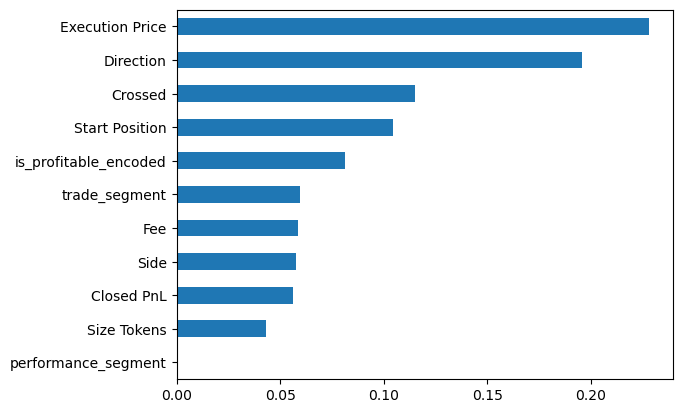

In [241]:
pd.Series(model_xg.feature_importances_, index=x_train.columns).sort_values().plot(kind='barh')
plt.show()

In [243]:
# Looking for train score and test score

print('-'*50, 'Train Score','-'*50)
model_xg_pred = model_rf.predict(x_train)
print('Accuracy Score',accuracy_score(y_train,model_xg_pred))
print('F1 Score',f1_score(y_train,model_xg_pred,average='macro'))
print('Cohen kappa Score',cohen_kappa_score(y_train,model_xg_pred))
print('\n classification_report\n',classification_report(y_train,model_xg_pred))


print('-'*50, 'Test Score','-'*50)
model_xg_pred = model_rf.predict(x_test)
print('Accuracy Score',accuracy_score(y_test,model_xg_pred))
print('F1 Score',f1_score(y_test,model_xg_pred,average='macro'))
print('Cohen kappa Score',cohen_kappa_score(y_test,model_xg_pred))
print('\n classification_report\n',classification_report(y_test,model_xg_pred))

-------------------------------------------------- Train Score --------------------------------------------------
Accuracy Score 0.733461952726455
F1 Score 0.7049265309957317
Cohen kappa Score 0.5789189112674802

 classification_report
               precision    recall  f1-score   support

           0       0.80      0.76      0.78     66547
           1       0.76      0.76      0.76     72309
           2       0.55      0.60      0.57     30118

    accuracy                           0.73    168974
   macro avg       0.70      0.71      0.70    168974
weighted avg       0.74      0.73      0.73    168974

-------------------------------------------------- Test Score --------------------------------------------------
Accuracy Score 0.7277956632894612
F1 Score 0.69953613739496
Cohen kappa Score 0.5702489779956368

 classification_report
               precision    recall  f1-score   support

           0       0.80      0.75      0.77     16690
           1       0.75      0.76     

***
***

### ***SUMMARY***

* This dataset is of cryptocurrency dataset which analysis the market sentiment on trading behaviour and performance. The dataset has 211218 rows and 21 columns.In this dataset there is no missing values and not having any duplicacy. I found that there is extreme outliers present in the data but we can't remove the data. We also can't cap all the data so , I cap the data which are extreme. I also did feature extraction like percentage p&l,win rate,trade_segement,is_profitable,clean_date etc. As my data has 2 dataframe for working on this dataframe I need to merge the data so , I merge it with clean date taking as common column.

* I also create correlation visualization where I got positive relation between fee and size USD. I also create some visualization charts where I got important insights as follows:

1) I got that mostly traders who are greed-driven mood get high profit than the traders who are in fear .
2) As the year passes traders trying to take more risk and became greed-driven traders. Through line chart visualization, I found that in the year of 2023 and 2024 there is stability in the market it is in breaK-even point. But, after 2024 end and 1st quarter of 2025 started the market growth increases by getting profit.
3) The traders who classified greed are more active in trading than the traders who classified as fear mood.

* As I need to build model. So, I use classification as my target variable but it has 5 classes so, building a model through these 5 categories would be very confusing.So, I combine extreme fear and fear and create one category same with extreme greed and greed. This helped me to build a model for 3 categories. As I have categorical column for prediction so, I used classification models for prediction.

* I also did scaling and encoding before moving to model building. I found class imbalance in the data so, I take class imbalance as the parameter during model creation.

* I create models like LogisticRegression, Random forest classifier and XG Boost Classifier as a model where I found Random forest and XG boost as the best model for prediction. As I got same score in Random and XGB so, I can take any model as my final model for prediction. I took XGB as my final model for prediction. I found that my model is generalized. I didn't face any issue of overfitting or underfitting.

* I also used RandomisedSearchCV for hyperparameter tuning because the dataset is too large so, using gridsearch cv wwould be very time consuming process which can't be done in jupyter file.

* I found that executive price is the important feature for prediction and size tokens are very less important feature for prediction. So, the company should more focus oon executive price than the size off tokens . The second most important feature is direction which is also crucial for the company to work on.

* I created a model which has 72 percent accuracy but my model is not for the real world prediction. There are following reasons for it:

1) As I can't say about the reliability of the data. If data is not reliable, These models are not good for prediction.
2) We need to keep this model under human supervision because when the data became outdated any new patterns came in the data so, the model can't able to predict accurately.
3) I also haven't much information about traders and this data. So, If any other external factors effected the data . This will lead to less accuracy in the model.



***
***